In [ ]:
# notebooks/02_exploratory_analysis.py

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# CONNECT DB
# ==========================================

con = duckdb.connect(
    "../data/warehouse/ecommerce.duckdb",
    read_only=True
)

1. USER FUNNEL ANALYSIS
  stage_name  user_count  conversion_rate
0       Cart      826317           0.2236
1   Purchase      441638           0.1195
2       View     3695598           1.0000


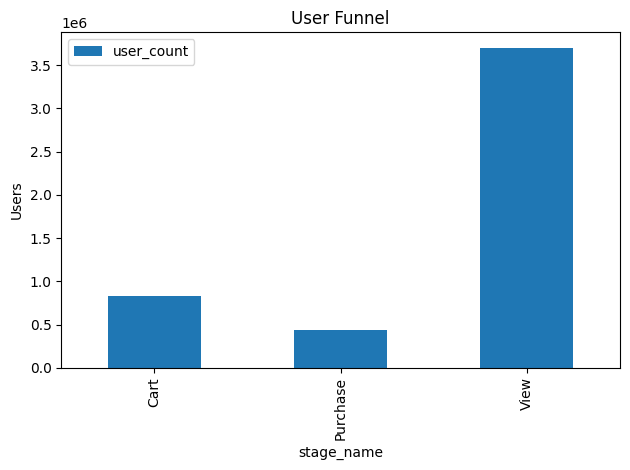

In [2]:
# ==========================================
# 1. USER FUNNEL ANALYSIS
# ==========================================

print("=" * 50)
print("1. USER FUNNEL ANALYSIS")
print("=" * 50)

df_funnel = con.execute("""
SELECT *
FROM mart_funnel
ORDER BY stage_name
""").df()

print(df_funnel)

df_funnel.plot(
    x="stage_name",
    y="user_count",
    kind="bar"
)

plt.title("User Funnel")
plt.ylabel("Users")
plt.tight_layout()
plt.show()

2. DAILY KPI ANALYSIS
  event_date  total_sessions  total_users  total_views  total_carts  \
0 2019-11-01          320904       223108      1403948        18349   
1 2019-11-02          338769       234685      1514263        18808   
2 2019-11-03          343373       240187      1525357        19538   
3 2019-11-04          396756       275612      1744242        21377   
4 2019-11-05          376362       262338      1673087        18800   

   total_purchases  total_revenue  session_conversion_rate  \
0            22457     6949402.19                 0.069980   
1            21863     6389578.47                 0.064537   
2            22145     6656920.09                 0.064493   
3            26889     8033899.65                 0.067772   
4            24872     7248731.79                 0.066085   

   average_order_value  
0           309.453720  
1           292.255339  
2           300.606010  
3           298.780157  
4           291.441452  


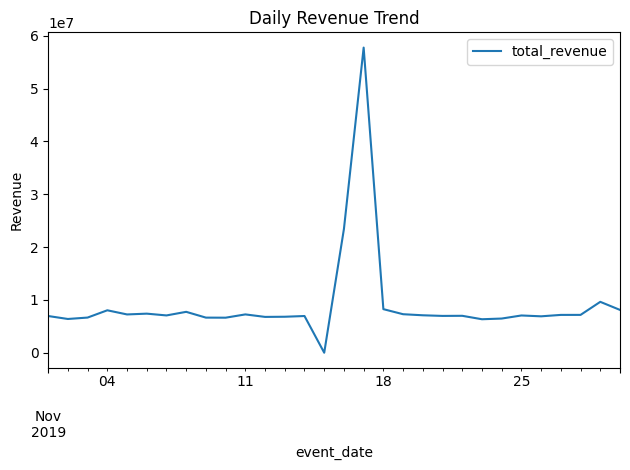

In [3]:
# ==========================================
# 2. DAILY KPI ANALYSIS
# ==========================================

print("=" * 50)
print("2. DAILY KPI ANALYSIS")
print("=" * 50)

df_kpi = con.execute("""
SELECT *
FROM mart_daily_kpis
ORDER BY event_date
""").df()

print(df_kpi.head())

df_kpi.plot(
    x="event_date",
    y="total_revenue"
)

plt.title("Daily Revenue Trend")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

3. CATEGORY PERFORMANCE
   category_group  purchases   sessions  conversion_rate
0     electronics   417810.0  5990736.0         0.069743
1                   208628.0  5108374.0         0.040840
2      appliances    88390.0  1643443.0         0.053783
3       computers    30140.0   933115.0         0.032300
4         apparel    12659.0   697283.0         0.018155
5       furniture    10333.0   523729.0         0.019730
6            auto    10054.0   307529.0         0.032693
7    construction     7998.0   251337.0         0.031822
8            kids     5598.0   262848.0         0.021297
9     accessories     2019.0   103340.0         0.019537
10          sport     1368.0    72296.0         0.018922
11       medicine      330.0     6229.0         0.052978
12     stationery      159.0     5192.0         0.030624
13   country_yard       60.0     5884.0         0.010197


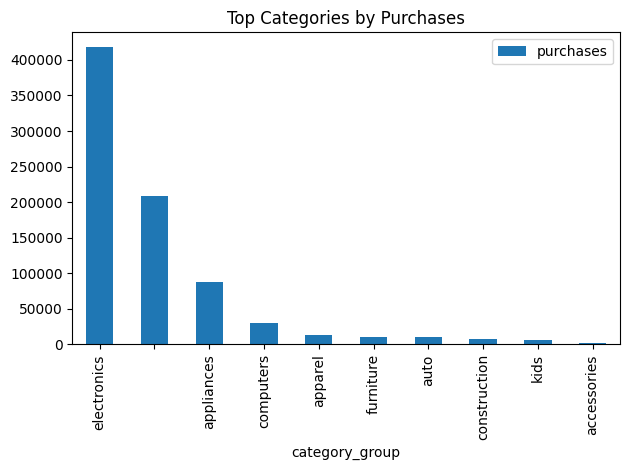

In [4]:
# ==========================================
# 3. CATEGORY PERFORMANCE
# ==========================================

print("=" * 50)
print("3. CATEGORY PERFORMANCE")
print("=" * 50)

df_category = con.execute("""
SELECT
    category_group,
    SUM(purchase_sessions) as purchases,
    SUM(total_sessions) as sessions,
    SUM(purchase_sessions)::DOUBLE /
        NULLIF(SUM(total_sessions),0) as conversion_rate
FROM int_daily_category_metrics
GROUP BY 1
ORDER BY purchases DESC
""").df()

print(df_category)

df_category.head(10).plot(
    x="category_group",
    y="purchases",
    kind="bar"
)

plt.title("Top Categories by Purchases")
plt.tight_layout()
plt.show()


4. TOP BRANDS
     brand  purchases       revenue
0    apple     166076  1.275173e+08
1  samsung     200035  5.487437e+07
2   xiaomi      68430  1.129264e+07
3       lg      12884  5.241162e+06
4   huawei      23726  4.798437e+06
5     sony      10312  3.865244e+06
6  lucente      14561  3.527662e+06
7     oppo      15080  3.488541e+06
8     acer       6424  3.355825e+06
9   lenovo       6589  2.714032e+06


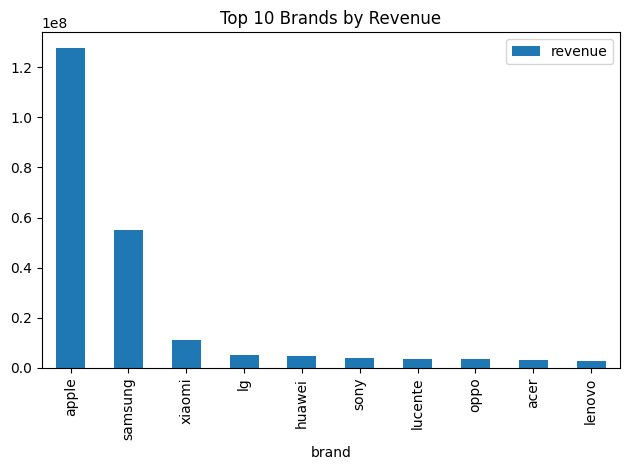

In [3]:
# ==========================================
# 4. TOP BRANDS
# ==========================================

print("=" * 50)
print("4. TOP BRANDS")
print("=" * 50)

df_brand = con.execute("""
SELECT *
FROM mart_brand_performance
ORDER BY revenue DESC
LIMIT 10
""").df()

print(df_brand)

df_brand.plot(
    x="brand",
    y="revenue",
    kind="bar"
)

plt.title("Top 10 Brands by Revenue")
plt.tight_layout()
plt.show()

5. CUSTOMER SEGMENTS
  customer_segment  total_customers
0  Needs Attention           119135
1  Loyal Customers           100490
2   Lost Customers            62833
3          At Risk            50103
4        Champions            43859
5    New Customers            37453
6   About To Sleep            27765


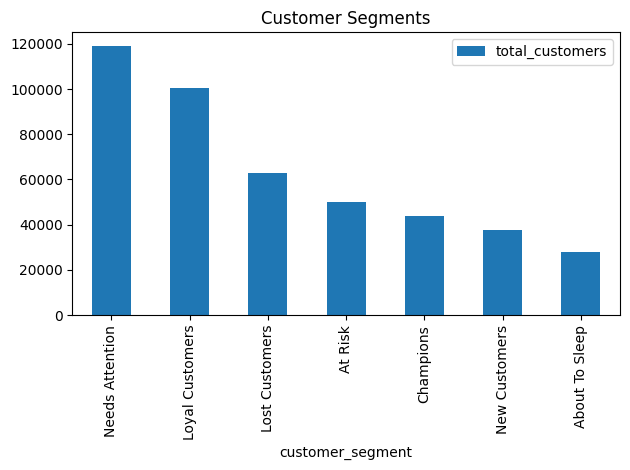

In [7]:
# ==========================================
# 5. CUSTOMER SEGMENTS
# ==========================================

print("=" * 50)
print("5. CUSTOMER SEGMENTS")
print("=" * 50)

df_segment = con.execute("""
SELECT
    customer_segment,
    COUNT(*) as total_customers
FROM mart_customer_segments
GROUP BY 1
ORDER BY total_customers DESC
""").df()

print(df_segment)

df_segment.plot(
    x="customer_segment",
    y="total_customers",
    kind="bar"
)

plt.title("Customer Segments")
plt.tight_layout()
plt.show()


6. RETENTION ANALYSIS
   cohort_index  retention_rate
0             0         1.00000
1             1         0.30975
2             2         0.29150
3             3         0.26165
4             4         0.27320


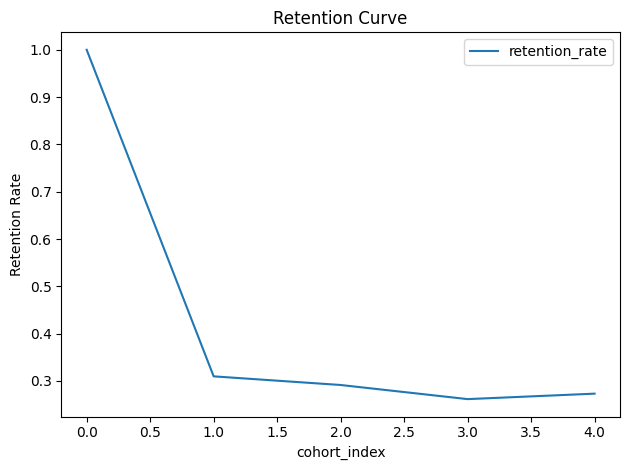

In [4]:
# ==========================================
# 6. RETENTION ANALYSIS
# ==========================================

print("=" * 50)
print("6. RETENTION ANALYSIS")
print("=" * 50)

df_retention = con.execute("""
SELECT
    cohort_index,
    AVG(retention_rate) as retention_rate
FROM mart_retention
GROUP BY 1
ORDER BY 1
""").df()

print(df_retention)

df_retention.plot(
    x="cohort_index",
    y="retention_rate"
)

plt.title("Retention Curve")
plt.ylabel("Retention Rate")
plt.tight_layout()
plt.show()


7. CAUSAL IMPACT ANALYSIS


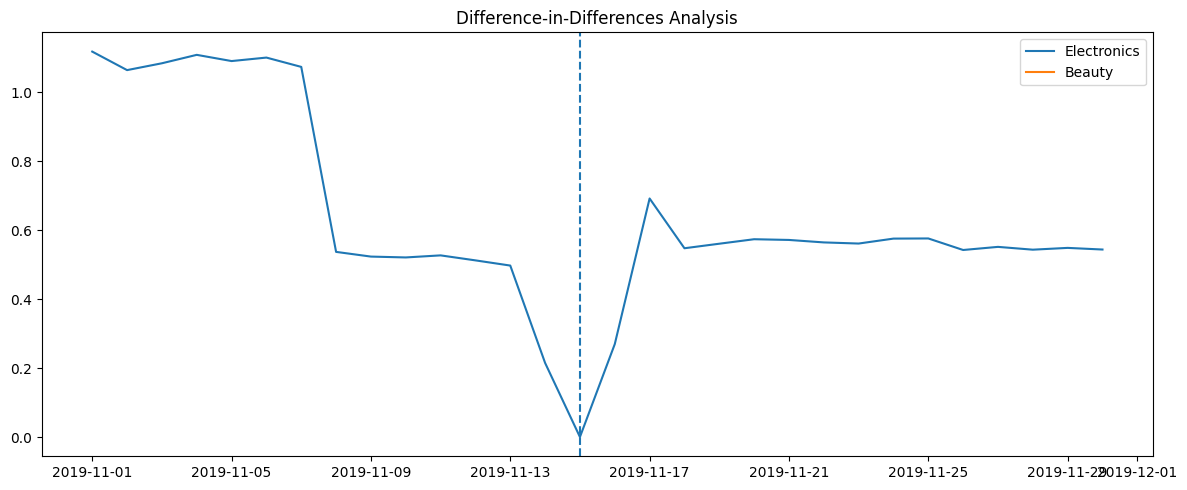

In [5]:
# ==========================================
# 7. CAUSAL IMPACT ANALYSIS
# ==========================================

print("=" * 50)
print("7. CAUSAL IMPACT ANALYSIS")
print("=" * 50)

df_did = con.execute("""
SELECT *
FROM mart_causal_did
ORDER BY event_date
""").df()

electronics = df_did[
    df_did["category_group"] == "electronics"
]

beauty = df_did[
    df_did["category_group"] == "beauty"
]

plt.figure(figsize=(12,5))

plt.plot(
    electronics["event_date"],
    electronics["cart_to_purchase_cr"],
    label="Electronics"
)

plt.plot(
    beauty["event_date"],
    beauty["cart_to_purchase_cr"],
    label="Beauty"
)

plt.axvline(
    pd.Timestamp("2019-11-15"),
    linestyle="--"
)

plt.legend()

plt.title(
    "Difference-in-Differences Analysis"
)

plt.tight_layout()
plt.show()

In [6]:
# ==========================================
# CLOSE
# ==========================================

con.close()